In [160]:
import pandas as pd
from alphagenome.data import genome
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt

In [ ]:
ALPHAGENOME_API_KEY = '' # TODO: fill in!
ORGAN = 'lung'
ROOT_DIR = 'data/pseudobulk'
PARQUET_PATH = f'{ROOT_DIR}/{ORGAN}_10x_pseudobulk.parquet'

In [162]:
df = pd.read_parquet(PARQUET_PATH) # Read pseudobulk data (cell type x gene)
df = df.reset_index()

In [163]:
# Create cell ontology ID mapping from dataset
cell_ontology = df[['cell_ontology_class', 'cell_ontology_id', 'n_cells']]
cell_ontology.set_index('cell_ontology_id', inplace=True)
cell_ontology.to_csv('test.csv')

In [164]:
expr_df = df.set_index('cell_ontology_id') # Set cell ontology ID as row index
expr_df.drop(columns=['cell_ontology_class', 'n_cells'], inplace=True) # Drop metadata columns
expr_df.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.14,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.17,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.15,...,ENSG00000290126.1,ENSG00000290127.1,ENSG00000290146.1,ENSG00000290147.1,ENSG00000290149.1,ENSG00000290162.1,ENSG00000290163.1,ENSG00000290164.1,ENSG00000290165.1,ENSG00000290166.1
cell_ontology_id,,,,,,,,,,,,,,,,,,,,,
CL:0002503,2.543483,0.625103,3.803460,2.314375,1.396129,1.675636,5.613580,3.822636,2.701026,2.472790,...,0.000000,0.625103,1.826262,0.0,0.625103,0.000000,0.360620,0.000000,0.360620,0.000000
CL:4028006,2.863065,0.538606,3.936892,2.771711,1.903440,1.856782,6.050867,3.375498,3.364983,2.582747,...,0.000000,0.927895,2.031622,0.0,0.411928,0.000000,0.266843,0.097077,0.342015,0.000000
CL:0000236,0.000000,0.000000,3.832133,2.508804,3.568543,2.433516,0.466386,1.379046,3.876202,3.160418,...,0.260140,1.301281,1.800205,0.0,0.783191,0.000000,0.637282,0.000000,0.637282,0.000000
CL:0000646,3.749575,0.134352,4.005284,2.777612,2.030068,2.107267,3.980081,2.831995,5.084023,2.463745,...,0.488031,0.641182,2.176896,0.0,0.358644,0.069431,0.118513,0.035318,0.419539,0.017815
CL:0000767,0.737750,0.114442,3.662288,2.083476,1.826745,2.928635,0.992311,3.532861,3.284829,2.782285,...,0.546666,1.036279,2.005001,0.0,3.329232,0.000000,0.310232,0.114442,0.114442,0.114442


In [165]:
# Read GTF file (refer to alphagenome_gtf.ipynb for how this was saved)
gtf = pd.read_parquet('data/metadata/alphagenome_gtf.parquet')
gtf.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,havana_transcript,exon_number,exon_id,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,gene_id_nopatch
0,chr1,HAVANA,gene,11868,14409,.,+,.,ENSG00000290825.1,lncRNA,...,None,None,None,None,None,None,None,None,None,ENSG00000290825
5,chr1,HAVANA,gene,12009,13670,.,+,.,ENSG00000223972.6,transcribed_unprocessed_pseudogene,...,None,None,None,HGNC:37102,OTTHUMG00000000961.2,None,None,None,None,ENSG00000223972
13,chr1,HAVANA,gene,14695,24886,.,-,.,ENSG00000227232.6,unprocessed_pseudogene,...,None,None,None,HGNC:38034,OTTHUMG00000000958.1,None,None,None,None,ENSG00000227232
25,chr1,ENSEMBL,gene,17368,17436,.,-,.,ENSG00000278267.1,miRNA,...,None,None,None,HGNC:50039,None,None,None,None,None,ENSG00000278267
28,chr1,HAVANA,gene,29553,31109,.,+,.,ENSG00000243485.5,lncRNA,...,None,None,None,HGNC:52482,OTTHUMG00000000959.2,None,None,None,None,ENSG00000243485


In [166]:
# Transpose pseudobulk data to have (genes x cell types) for merging with GTF genes
expr_df = expr_df.T
expr_df = expr_df.reset_index().rename(columns={'index': 'gene_id'})
expr_df.columns.name = None
expr_df.head()

,gene_id,CL:0002503,CL:4028006,CL:0000236,CL:0000646,CL:0000767,CL:0002598,CL:0002144,CL:0000624,CL:0000625,...,CL:0000775,CL:0000875,CL:0000669,CL:0000786,CL:0017000,CL:0002370,CL:0002062,CL:0002063,CL:0000359,CL:0002543
0,ENSG00000000003.15,2.543483,2.863065,0.000000,3.749575,0.737750,2.169129,2.321581,0.839957,0.498597,...,0.506439,0.915168,1.303493,0.777047,3.769139,3.979929,2.006843,2.279340,1.480118,3.546741
1,ENSG00000000005.6,0.625103,0.538606,0.000000,0.134352,0.114442,1.001502,0.138661,0.096447,0.000000,...,0.000000,0.000000,0.218196,0.000000,0.000000,0.223385,0.000000,0.003014,0.000000,0.545072
2,ENSG00000000419.14,3.803460,3.936892,3.832133,4.005284,3.662288,3.725106,3.923714,4.012243,3.964859,...,3.718964,3.687055,3.831001,3.333130,3.666339,3.821086,3.973923,3.914888,3.731019,4.028064
3,ENSG00000000457.14,2.314375,2.771711,2.508804,2.777612,2.083476,2.348803,3.053912,3.116468,3.156791,...,2.652357,2.359159,2.946724,1.869264,2.617602,2.773719,2.583896,2.163842,2.510538,2.610830
4,ENSG00000000460.17,1.396129,1.903440,3.568543,2.030068,1.826745,1.001502,2.177409,3.496368,2.556758,...,1.725549,2.440638,2.254872,1.592658,1.655228,1.925278,1.542608,1.473892,1.895485,3.200866


In [167]:
# Calculate mean and variance expression across all cell types
cell_cols = expr_df.columns.difference(['gene_id'])
expr_df['mean_expr'] = expr_df[cell_cols].mean(axis=1)
expr_df['var_expr'] = expr_df[cell_cols].var(axis=1)

In [168]:
# Merge the pseudobulk data with the GTF annotation to get genomic coordinates for each gene
expr_df_merged = expr_df.merge(gtf[[
    'gene_id', 'gene_name', 'Chromosome', 'Start', 'End', 'Strand'
]], on='gene_id', how='inner') # Drop genes in dataset that don't have available coordinates
expr_df_merged.rename(columns={'Chromosome':'chromosome', 'Start':'start', 'End':'end', 'Strand':'strand'}, inplace=True)
assert len(expr_df_merged) <= len(expr_df)
expr_df_merged.head()

,gene_id,CL:0002503,CL:4028006,CL:0000236,CL:0000646,CL:0000767,CL:0002598,CL:0002144,CL:0000624,CL:0000625,...,CL:0002063,CL:0000359,CL:0002543,mean_expr,var_expr,gene_name,chromosome,start,end,strand
0,ENSG00000000005.6,0.625103,0.538606,0.000000,0.134352,0.114442,1.001502,0.138661,0.096447,0.000000,...,0.003014,0.000000,0.545072,0.156577,0.058831,TNMD,chrX,100584935,100599885,+
1,ENSG00000000419.14,3.803460,3.936892,3.832133,4.005284,3.662288,3.725106,3.923714,4.012243,3.964859,...,3.914888,3.731019,4.028064,3.854035,0.030219,DPM1,chr20,50934866,50959140,-
2,ENSG00000000457.14,2.314375,2.771711,2.508804,2.777612,2.083476,2.348803,3.053912,3.116468,3.156791,...,2.163842,2.510538,2.610830,2.608245,0.137729,SCYL3,chr1,169849630,169894267,-
3,ENSG00000000460.17,1.396129,1.903440,3.568543,2.030068,1.826745,1.001502,2.177409,3.496368,2.556758,...,1.473892,1.895485,3.200866,2.160756,0.444036,FIRRM,chr1,169662006,169854080,+
4,ENSG00000000938.13,1.675636,1.856782,2.433516,2.107267,2.928635,2.569292,4.678538,2.025689,3.088480,...,1.315380,1.480118,3.417615,3.168826,2.262834,FGR,chr1,27612063,27635185,-


In [169]:
# Iterate through the dataset and create genomic intervals for each gene (object definition in AlphaGenome library)
intervals = [genome.Interval(
    chromosome=gene.chromosome,
    start=gene.start,
    end=gene.end,
    strand=gene.strand,
    name=gene.gene_id,
) for gene in expr_df_merged.itertuples(index=False)]

In [174]:
model = dna_client.create(ALPHAGENOME_API_KEY) # Create AlphaGenome model client

In [175]:
model_metadata = model.output_metadata().rna_seq

In [176]:
# Map from anatomical part (organ/tissue) name to UBERON ID in AlphaGenome metadata
uberon_mapping = model_metadata[model_metadata['ontology_curie'].str.contains('^UBERON:', regex=True)].set_index('biosample_name')['ontology_curie'].to_dict()

In [177]:
data_cell_types = [col for col in expr_df_merged.columns if col.startswith('CL:')]
model_cell_types = list(set([ont for ont in model_metadata['ontology_curie'] if ont.startswith('CL:')]))

# Print which data cell types are and are not in the model
print("Cell types represented in model:", set(data_cell_types).intersection(model_cell_types))
print("Cell types not represented in model:", set(data_cell_types).difference(model_cell_types))

Cell types represented in model: {'CL:0000624', 'CL:0000623', 'CL:0000236', 'CL:0000625', 'CL:0002598', 'CL:0002543'}
Cell types not represented in model: {'CL:0002393', 'CL:0000860', 'CL:0000359', 'CL:0002144', 'CL:0017000', 'CL:0000775', 'CL:0000235', 'CL:0000875', 'CL:0000576', 'CL:0002063', 'CL:0000669', 'CL:0000786', 'CL:0000158', 'CL:1000271', 'CL:1000413', 'CL:0002503', 'CL:0002370', 'CL:0000767', 'CL:0002138', 'CL:0000814', 'CL:4028006', 'CL:0000646', 'CL:0002062'}


In [179]:
N = 5 # ~0.65 seconds per 1Mb interval on CPU
outputs = [model.predict_interval(
    interval=interval.resize(dna_client.SEQUENCE_LENGTH_1MB),
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=[uberon_mapping[ORGAN]], # 'CL:0000624'
) for interval in intervals[:N]] # Run on first N genes for testing

In [ ]:
print(outputs[0].rna_seq.resolution) # 1bp resolution

1


In [181]:
def filter_rna_seq_output(rna_seq, interval):
    rna_seq_metadata = rna_seq.metadata
    rna_seq_metadata = rna_seq_metadata[rna_seq_metadata['strand'] == interval.strand]
    rna_seq_metadata = rna_seq_metadata[rna_seq_metadata['Assay title'] == 'polyA plus RNA-seq']
    rna_seq = rna_seq.filter_tracks([True if i == rna_seq_metadata.index else False for i in range(rna_seq.num_tracks)])
    return rna_seq

In [182]:
rna_seqs = [filter_rna_seq_output(outputs[i].rna_seq, intervals[i]) for i in range(N)]

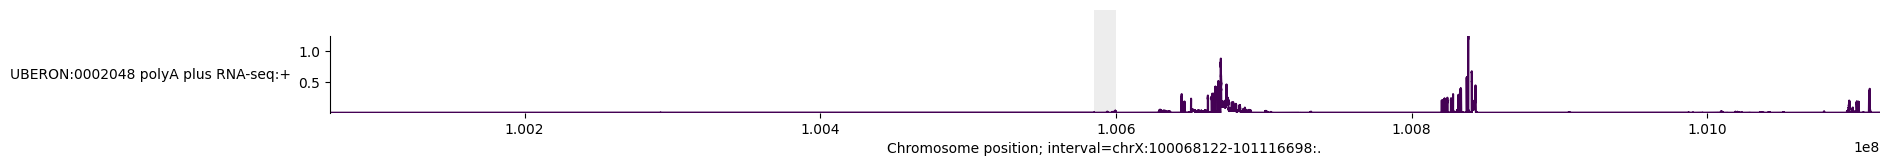

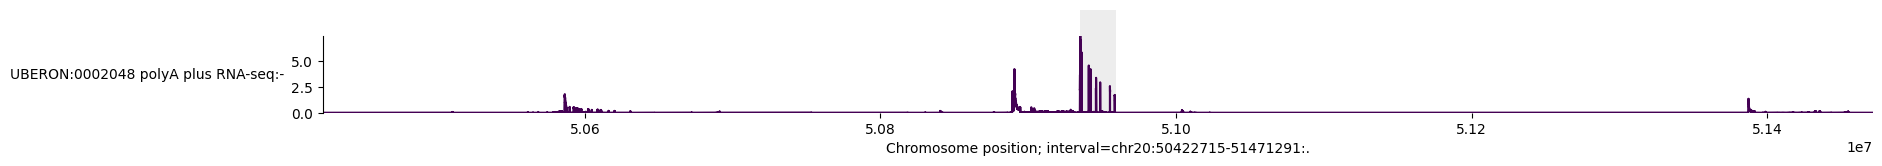

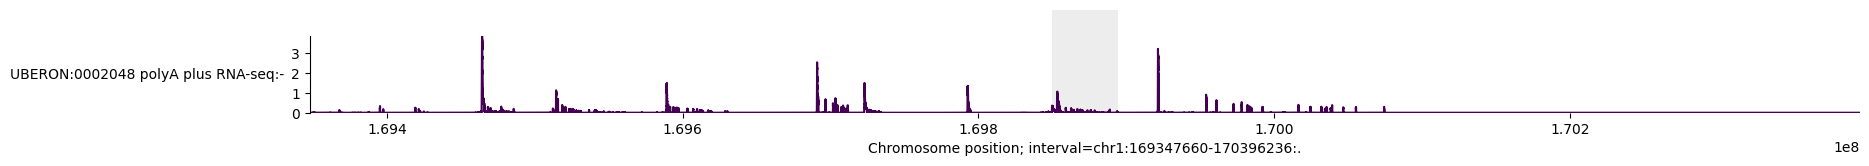

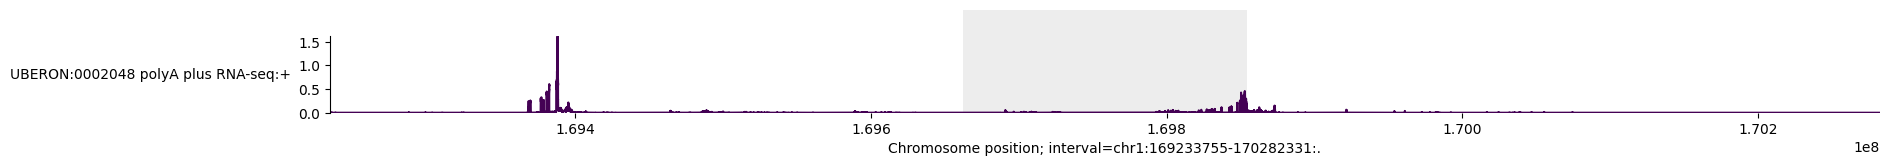

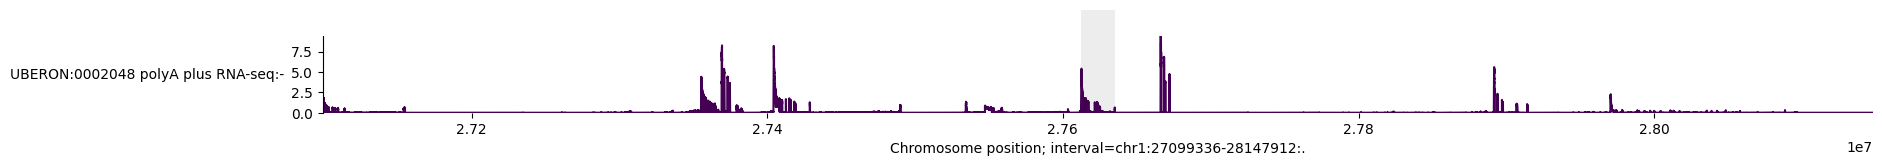

In [183]:
for i in range(5):
    plot_components.plot(
        components=[
            plot_components.Tracks(rna_seqs[i]),
        ],
        interval=rna_seqs[i].interval, # Show the full 1MB window 
        annotations=[ # Highlight the original interval (gene)
            plot_components.IntervalAnnotation([intervals[i]]),
        ],
    )
    plt.show()

In [184]:
track_start = rna_seqs[0].interval.start
gene_start = intervals[0].start - track_start
gene_end = intervals[0].end - track_start

In [185]:
rna_seq_gene = rna_seqs[0][gene_start:gene_end]

In [186]:
gene_expr = rna_seq_gene.values.sum() # Total expression across the gene body
print(gene_expr)

16.333546
